# Gradient Descent in One Variable — Part 2 (The Algorithm)

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on **gradient descent**
(Week 2 — Gradients and Gradient Descent).

This notebook explains:

- how the **derivative tells you which way to step** toward the minimum
- the update rule $x_{\text{new}} = x_{\text{old}} - \alpha\, f'(x_{\text{old}})$
- the **learning rate** $\alpha$ and why we need it
- the "steep → big step, flat → small step" (golf) intuition
- the full algorithm, worked on $f(x) = e^{x} - \ln x$ from $x_0 = 0.05$
- a Python implementation, convergence to the Omega constant, and learning-rate effects

This notebook follows the repository `GUIDELINES.md` template and continues directly
from *Gradient Descent in One Variable — Part 1*.

## 1. From naive search to using the slope

In Part 1 we sampled left and right and stepped toward the smaller value. We can do
something **smarter** using the **derivative**:

- If you are **left** of the minimum, the slope is **negative** → you want to move
  **right**.
- If you are **right** of the minimum, the slope is **positive** → you want to move
  **left**.

In both cases the right move is **opposite to the sign of the slope**. So:

$$
x_{\text{new}} = x_{\text{old}} - f'(x_{\text{old}}).
$$

- Left of the minimum: $f' < 0$, subtracting a negative **adds** → moves right. ✔
- Right of the minimum: $f' > 0$, subtracting a positive → moves left. ✔

## 2. The learning rate $\alpha$

> *"Imagine you're at a very steep part of the curve. The derivative is very large, so
> it's making a really long jump... you may miss the minimum and get lost."*

A raw step of $f'(x)$ can be **too big** and overshoot. We damp it with a small factor
$\alpha$ — the **learning rate** (e.g. $0.01$):

$$
\boxed{\,x_{k} = x_{k-1} - \alpha\, f'(x_{k-1})\,}
$$

> *"There's a whole science in picking good learning rates."*

### Built-in adaptivity (the golf analogy)

The update has a nice bonus: the step size **automatically** scales with steepness.

- **Steep** region → large $|f'|$ → relatively **big** step (you're far away).
- **Flat** region near the minimum → small $|f'|$ → **small** step (precision).

> *"Like golf: far from the hole you hit hard; close to it you hit with precision."*

## 3. The algorithm

> *"You never need to solve $f'(x) = 0$. You only need to know the derivative and apply it
> in the updating step."*

1. Choose a **learning rate** $\alpha$ and a **starting point** $x_0$.
2. Repeat the **update**: $\;x_k = x_{k-1} - \alpha\, f'(x_{k-1})$.
3. **Stop** when the steps barely change (you're close enough to the minimum).

This avoids solving any equation — it only **evaluates** the derivative.

## 4. Worked example: $f(x) = e^{x} - \ln x$

Recall $f'(x) = e^{x} - \dfrac{1}{x}$. Take a starting point $x_0 = 0.05$ and learning
rate $\alpha = 0.005$.

**Iteration 1.**
$f'(0.05) = e^{0.05} - \tfrac{1}{0.05} = 1.0513 - 20 = -18.949$,

$$
x_1 = 0.05 - 0.005\,(-18.949) = 0.1447.
$$

**Iteration 2.**
$f'(0.1447) = e^{0.1447} - \tfrac{1}{0.1447} = 1.1557 - 6.911 = -5.755$,

$$
x_2 = 0.1447 - 0.005\,(-5.755) = 0.1735.
$$

Each step moves us closer to the minimum (the Omega constant $\approx 0.5671$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.exp(x) - np.log(x)

def fprime(x):
    return np.exp(x) - 1/x

# reproduce the first two iterations from the lecture
x0, alpha = 0.05, 0.005
x1 = x0 - alpha * fprime(x0)
x2 = x1 - alpha * fprime(x1)
print(f"f'(0.05)   = {fprime(0.05):.4f}")
print(f"x1 = {x1:.4f}")
print(f"f'({x1:.4f}) = {fprime(x1):.4f}")
print(f"x2 = {x2:.4f}")

f'(0.05)   = -18.9487
x1 = 0.1447
f'(0.1447) = -5.7530
x2 = 0.1735


## 5. Implementing gradient descent

In [2]:
def gradient_descent(fprime, x0, alpha=0.005, n_steps=2000, tol=1e-8):
    x = x0
    history = [x]
    for _ in range(n_steps):
        step = alpha * fprime(x)
        x = x - step
        history.append(x)
        if abs(step) < tol:          # steps barely change -> stop
            break
    return x, np.array(history)

x_min, hist = gradient_descent(fprime, x0=0.05, alpha=0.005)
omega = 0.5671432904
print(f"Gradient descent result: x = {x_min:.6f}")
print(f"Omega constant (true)  : {omega:.6f}")
print(f"Iterations: {len(hist) - 1}")
print(f"First few iterates: {np.round(hist[:5], 4)}")

Gradient descent result: x = 0.567143
Omega constant (true)  : 0.567143
Iterations: 542
First few iterates: [0.05   0.1447 0.1735 0.1964 0.2158]


## 6. Visualizing the descent

Left: the path of iterates sliding down $f$ toward the minimum. Right: the value $f(x_k)$
decreasing with each iteration.

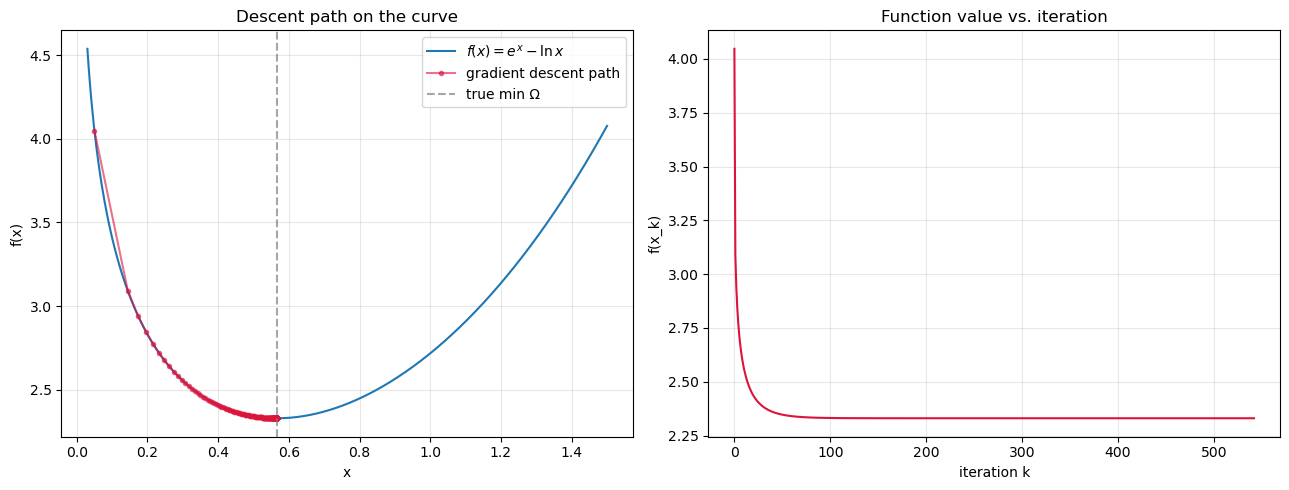

In [3]:
xs = np.linspace(0.03, 1.5, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(xs, f(xs), label=r"$f(x)=e^{x}-\ln x$")
axes[0].plot(hist, f(hist), "o-", color="crimson", markersize=3, alpha=0.6,
             label="gradient descent path")
axes[0].axvline(0.5671432904, color="gray", linestyle="--", alpha=0.7, label="true min Ω")
axes[0].set_title("Descent path on the curve")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].plot(f(hist), color="crimson")
axes[1].set_title("Function value vs. iteration")
axes[1].set_xlabel("iteration k"); axes[1].set_ylabel("f(x_k)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. The effect of the learning rate

$\alpha$ controls the trade-off:

- **too small** → very slow convergence (many tiny steps),
- **too large** → overshoot, oscillation, or divergence,
- **just right** → fast, stable descent.

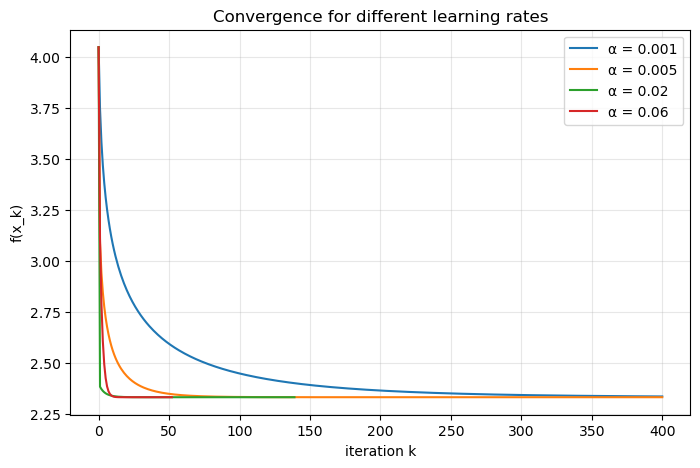

In [4]:
plt.figure(figsize=(8, 5))
for a in [0.001, 0.005, 0.02, 0.06]:
    _, h = gradient_descent(fprime, x0=0.05, alpha=a, n_steps=400)
    plt.plot(f(h), label=f"α = {a}")
plt.title("Convergence for different learning rates")
plt.xlabel("iteration k"); plt.ylabel("f(x_k)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 8. Exercises

### Basic
1. Write the gradient-descent update rule and name each symbol.
2. If the slope at your current point is negative, which way does the update move you?

### Intermediate
3. Starting from $x_0 = 0.05$ with $\alpha = 0.005$, compute $x_1$ and $x_2$ by hand for
   $f(x) = e^{x} - \ln x$, and check against the code.
4. Run gradient descent with $\alpha = 0.001$ and with $\alpha = 0.02$. Which reaches the
   minimum in fewer iterations?

### Advanced
5. Apply gradient descent to $g(x) = x^2$ (so $g'(x) = 2x$) from $x_0 = 5$. Show that the
   update becomes $x_k = (1 - 2\alpha)\,x_{k-1}$ and discuss for which $\alpha$ it
   converges.
6. Explain, using the formula, why gradient descent takes larger steps far from the
   minimum and smaller steps near it.

## 9. Solutions / Checks

In [5]:
# 3. by-hand iterations
x0, alpha = 0.05, 0.005
x1 = x0 - alpha * fprime(x0)
x2 = x1 - alpha * fprime(x1)
print(f"3. x1 = {x1:.4f}, x2 = {x2:.4f}  (lecture: 0.1447, 0.1735)")

# 4. compare learning rates
for a in (0.001, 0.02):
    xm, h = gradient_descent(fprime, 0.05, alpha=a, n_steps=20000)
    print(f"4. α={a}: reached x={xm:.5f} in {len(h)-1} iterations")

# 5. g(x)=x^2
def gprime(x): return 2*x
xm, h = gradient_descent(gprime, x0=5.0, alpha=0.1, n_steps=200)
print(f"5. g(x)=x^2 from 5 with α=0.1 -> x={xm:.6f}; "
      "update is x_k=(1-2α)x_(k-1), converges when |1-2α|<1, i.e. 0<α<1.")

print("6. The step is α·f'(x): large |f'| (steep) -> big step, small |f'| (flat near min) -> small step.")

3. x1 = 0.1447, x2 = 0.1735  (lecture: 0.1447, 0.1735)
4. α=0.001: reached x=0.56714 in 2410 iterations
4. α=0.02: reached x=0.56714 in 139 iterations
5. g(x)=x^2 from 5 with α=0.1 -> x=0.000000; update is x_k=(1-2α)x_(k-1), converges when |1-2α|<1, i.e. 0<α<1.
6. The step is α·f'(x): large |f'| (steep) -> big step, small |f'| (flat near min) -> small step.


## 10. Conclusion

- Gradient descent steps **opposite to the slope**, scaled by a **learning rate**:

$$
x_k = x_{k-1} - \alpha\, f'(x_{k-1}).
$$

- The learning rate $\alpha$ keeps steps safe; the derivative makes steps **adaptive** —
  big on steep parts, small near the (flat) minimum.
- It is **iterative** and never solves $f'(x) = 0$ — only evaluates $f'$ — so it works
  where analytical methods fail, and runs thousands of cheap iterations fast.
- This is the workhorse of machine-learning optimization; next it generalizes to
  **several variables** using the gradient vector.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/gradient2.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 2) lecture on **gradient descent in one variable**. Key spoken points,
lightly cleaned:

> Use the derivative to decide the step: left of the minimum the slope is negative (move
> right), right of it the slope is positive (move left) — so move opposite to the slope:
> $x_{\text{new}} = x_{\text{old}} - f'(x_{\text{old}})$. But a steep part gives a large
> derivative and a chaotic long jump, so multiply by a small learning rate $\alpha$ (e.g.
> $0.01$): $x_k = x_{k-1} - \alpha f'(x_{k-1})$. This is adaptive — big steps where steep,
> small where flat (like golf). Iterate many times until steps barely change. Example:
> $f(x)=e^{x}-\ln x$, $f'(x)=e^{x}-1/x$, start $x_0=0.05$, $\alpha=0.005$ → $x_1=0.1447$,
> $x_2=0.1735$, and so on. You never solve $f'(x)=0$; you only evaluate the derivative —
> a huge improvement.